# Test 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from tqdm import tqdm

from wavelet_utils import loadFilterParamDict
from analysis_utils import apply_model, fit_model, smooth_stimulus_signals

Expecting to have:
* Cell database: cell_database_waven1.pickle having records for each neuron 

In [2]:
# Path definitions
data_path = r"D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS"

temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

lib_dim="40_26_8_5_4_2"

libpath= Path(temppath) / f'gaborLibrary_{lib_dim}.npy'
paramspath = libpath.with_suffix('.json')   

downsampled_video_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled.npy"

In [3]:
# Load inputs
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(paramspath)

input_pickle= Path(data_path) / "cell_database_waven1.pickle"
df_cells=pd.read_pickle(input_pickle)

df_cells

,cell_id,SeriesID,SNR,R_value,CNN,Accepted,X_pix,Y_pix,contour,RF_indexes,...,tuning_angles,tuning_sizes,tuning_freqs,Repeatability,RF_value,Azimuth,Elevation,Angle,Size,Frequency
cell_id,,,,,,,,,,,,,,,,,,,,,
0,0,g11_0409_zebra5,3.702055,0.846081,0.695202,True,5.318614,10.911077,"[[nan, nan], [4.108625215102572, 15.0], [5.0, ...","[17, 20, 7, 3, 2]",...,"[[0.036998488, 0.031761996, -0.0069221547, -0....","[[0.010737955, 0.022543536, 0.049963947, 0.042...","[[0.013249312, 0.011474189, 0.0049129943, -0.0...",0.573633,0.300386,-50.625,17.307692,2.748894,9.525249,0.05848
1,1,g11_0409_zebra5,2.699508,0.868755,0.999747,True,7.631077,33.129955,"[[nan, nan], [8.669051077958464, 36.0], [9.0, ...","[17, 23, 1, 3, 3]",...,"[[-0.007410328, -0.012710833, -0.028777959, -0...","[[-0.009180402, -0.0049155867, 0.0025587752, -...","[[-0.0029240772, -0.0038421182, -0.0071217995,...",0.695063,0.421140,-50.625,24.230769,0.392699,9.525249,0.10000
2,2,g11_0409_zebra5,1.568210,0.402314,0.904663,False,15.634632,26.354231,"[[nan, nan], [19.690770239130163, 30.0], [20.0...","[13, 19, 0, 1, 3]",...,"[[0.017827637, 0.021306101, 0.020752335, 0.004...","[[0.021634363, 0.033503354, 0.05863058, 0.0619...","[[0.014214031, 0.014632598, 0.015743088, 0.019...",0.424936,0.269256,-59.625,15.000000,0.000000,4.409334,0.10000
3,3,g11_0409_zebra5,1.922118,0.806961,0.981885,True,17.569790,33.833533,"[[nan, nan], [19.832363490075355, 36.0], [20.0...","[9, 21, 7, 4, 0]",...,"[[-0.003102894, -0.0031757269, -0.003397209, -...","[[0.0048153433, 0.004538589, 0.0037520952, 0.0...","[[0.005151025, 0.005531297, 0.006861886, 0.011...",0.607133,0.267179,-68.625,19.615385,2.748894,14.000000,0.02000
4,4,g11_0409_zebra5,1.249761,0.629703,0.629156,False,34.205115,5.517506,"[[nan, nan], [33.77605088223731, 10.0], [34.0,...","[12, 25, 2, 4, 2]",...,"[[-0.030476313, -0.03200161, -0.015091008, 0.0...","[[-0.042745445, -0.0414103, -0.01739278, 0.019...","[[-0.030173428, -0.030270707, -0.030334804, -0...",0.485067,0.168119,-61.875,28.846154,0.785398,14.000000,0.05848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249,2249,g11_0409_zebra5,1.561412,0.788473,0.999880,True,338.390643,140.038287,"[[nan, nan], [340.56224472995206, 143.0], [341...","[18, 25, 2, 4, 1]",...,"[[0.010921994, 0.01101075, 0.008539401, -0.012...","[[-0.012994938, -0.010607252, -0.0022490234, 0...","[[-0.01200438, -0.012863778, -0.015808463, -0....",0.517633,0.245082,-48.375,28.846154,0.785398,14.000000,0.03420
2250,2250,g11_0409_zebra5,1.986334,0.834088,0.999340,True,128.793998,181.354349,"[[nan, nan], [131.0325258846103, 184.0], [132....","[23, 0, 3, 3, 3]",...,"[[-0.0028225242, -0.01517332, -0.042951398, -0...","[[-0.017979208, -0.00014875625, 0.058366206, 0...","[[-0.030355567, -0.03132006, -0.0344816, -0.04...",0.149377,0.170346,-37.125,-28.846154,1.178097,9.525249,0.10000
2251,2251,g11_0409_zebra5,2.417578,0.810271,0.890795,True,347.983284,254.186628,"[[nan, nan], [350.61445700363845, 258.0], [350...","[27, 23, 3, 4, 0]",...,"[[-0.0035404968, -0.004322167, -0.007262435, -...","[[-0.016848894, -0.0142035885, -0.005533018, 0...","[[-0.019040948, -0.020873908, -0.027102325, -0...",0.183490,0.281719,-28.125,24.230769,1.178097,14.000000,0.02000


In [4]:
resolution = 2.14 # um/px

In [5]:
#collecting inputs

        
n_neurons = len(df_cells)
n_timepoints = len(df_cells.iloc[0]['WL_transient_phase']) # assume each entry has the same length
        
phi_all  = np.empty((n_neurons, n_timepoints), dtype=float)
dphi_all = np.empty((n_neurons, n_timepoints), dtype=float)
rho_all  = np.empty((n_neurons, n_timepoints), dtype=float)
spks_all = np.empty((n_neurons, n_timepoints), dtype=float)

respcorr = np.empty((n_neurons), dtype=float)

for i, (_idx, row) in enumerate(df_cells.iterrows()):
        
    rho=np.sqrt(row['WL_transient_squared'])  
    phi=(row['WL_transient_phase'])
    dphi = np.diff(np.unwrap(phi), prepend=0)
    
    #dphi[abs(dphi) >= 3] = np.nan
    #nans, x = nan_helper(dphi)
    #dphi[nans] = np.interp(x(nans), x(~nans), dphi[~nans])
    
    spks=row['Activity_mean']
    
    rho_all[i]  = rho
    phi_all[i]  = phi
    dphi_all[i] = dphi
    spks_all[i] = spks
    
    respcorr[i] = row["Repeatability"]
             

In [6]:
average_FWHM_samples = 9 #smoothing

hanning_window=8

train_split=0.9
train_split_index=int(rho_all.shape[1]*train_split)

X_corr = np.empty((n_neurons), dtype=float)
Full_corr = np.empty((n_neurons), dtype=float)
Zs=[]

largest_respcorr_indices = np.argsort(respcorr)[-20:]

torun=range(n_neurons)
#torun=largest_respcorr_indices #carfully!

for i in tqdm(torun):
    
        #plot
        rho = rho_all[i]
        phi = phi_all[i]
        dphi = dphi_all[i]
        spks = spks_all[i]
        
        rho_train=rho[:train_split_index]
        phi_train=phi[:train_split_index]
        dphi_train=dphi[:train_split_index]
        spks_train=spks[:train_split_index]
        
        rho_test=rho[train_split_index:]
        phi_test=phi[train_split_index:]
        dphi_test=dphi[train_split_index:]
        spks_test=spks[train_split_index:]
        
        
        interpolator, Z, rho_centers, phi_centers, dphi_centers=fit_model(rho_train, phi_train, dphi_train, spks_train, hanning_window=hanning_window, smooth_stim_FWHM_samples=average_FWHM_samples)
        Zs.append(Z)
        
        pred_spks_test=apply_model(interpolator, rho_test, phi_test, dphi_test, smooth_stim_FWHM_samples=average_FWHM_samples)
        
        X_corr[i] = np.corrcoef(spks_test, pred_spks_test)[0, 1]
        
        pred_spks_train=apply_model(interpolator, rho_train, phi_train, dphi_train, smooth_stim_FWHM_samples=average_FWHM_samples)
        
        Full_corr[i] = np.corrcoef(np.concatenate([spks_train, spks_test]), np.concatenate([pred_spks_train, pred_spks_test]))[0, 1] 
            
#index of largest 20 respcorr values

print(f"Mean respcorr of largest 20 neurons: {np.mean(respcorr[largest_respcorr_indices])}")
print(f"Mean correlation of largest 20 neurons: {np.mean(X_corr[largest_respcorr_indices])}")

100%|██████████| 2254/2254 [00:47<00:00, 47.89it/s]

Mean respcorr of largest 20 neurons: 0.734815765831713
Mean correlation of largest 20 neurons: 0.3417367371029435


In [7]:
print(f"Mean correlation of respcorr>0.2 neurons: {np.mean(X_corr[respcorr>0.2])}")

Mean correlation of respcorr>0.2 neurons: 0.21324873946541112


In [8]:
 # plotting temporal curves
 %matplotlib widget
 def plot_model(rho_original, phi_original, dphi_original, spks, pred, title="", smooth_stim_FWHM_samples=0):
   
    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    
    x=np.argmax(spks)
    print(x)
    
    rho, phi, dphi = smooth_stimulus_signals(rho_original, phi_original, dphi_original, smooth_stim_FWHM_samples)
    
    signals = [rho, phi, dphi]
    signals_original = [rho_original, phi_original, dphi_original]
    names = ["rho", "phi", "dphi"]

    for ax, sig, sig_o, name in zip(axes, signals, signals_original, names):
        # left axis: actual vs predicted
        ax.plot(spks, label="actual", color="black")
        ax.plot(pred, label="predicted", color="red", alpha=0.7)
        ax.set_ylabel("spks / pred")

        # right axis: feature
        ax_r = ax.twinx()
        ax_r.plot(sig_o, label=name, color="green", alpha=0.2)
        ax_r.plot(sig, label=name, color="blue", alpha=0.4)
        ax_r.set_ylabel(name)

        ax.set_title(name)

    window = 400
    axes[0].set_xlim(x-window, x+window)
    # legend only once (cleaner)
    axes[0].legend(loc="upper left")
    fig.suptitle(title)
    plt.xlabel("time")
    plt.tight_layout()
    plt.show()

1210


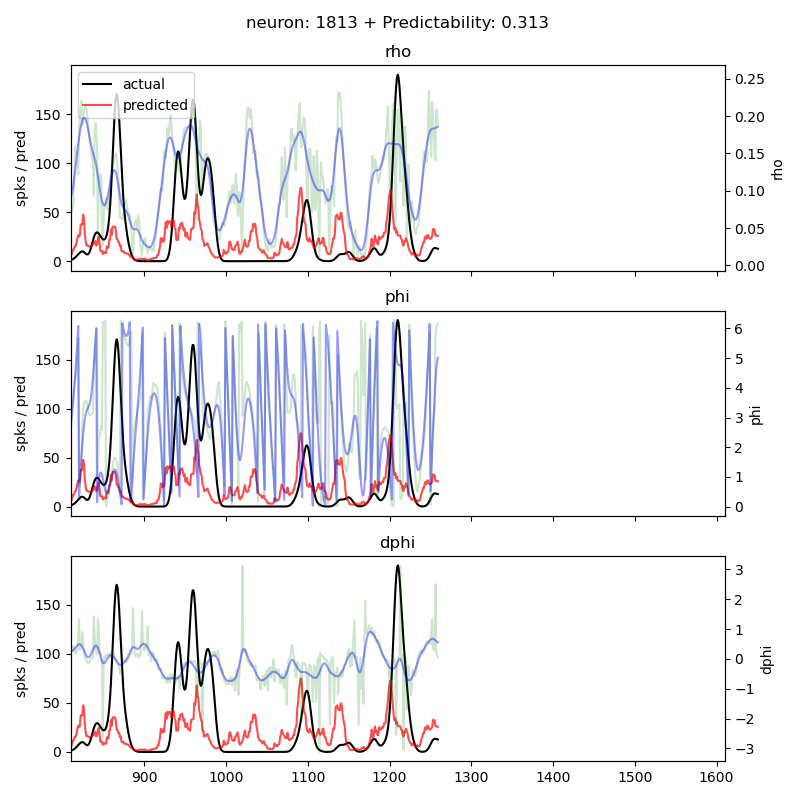

In [ ]:
testneuron=30
#testneuron=456
testneuron=1813

rho = rho_all[testneuron]
phi = phi_all[testneuron]
dphi = dphi_all[testneuron]
spks = spks_all[testneuron]

rho_train=rho[:train_split_index]
phi_train=phi[:train_split_index]
dphi_train=dphi[:train_split_index]
spks_train=spks[:train_split_index]

rho_test=rho[train_split_index:]
phi_test=phi[train_split_index:]
dphi_test=dphi[train_split_index:]
spks_test=spks[train_split_index:]
         
interpolator, Z, rho_centers, phi_centers, dphi_centers=fit_model(rho_train, phi_train, dphi_train, spks_train, hanning_window=hanning_window, smooth_stim_FWHM_samples=average_FWHM_samples)

pred_spks_test=apply_model(interpolator, rho_test, phi_test, dphi_test, smooth_stim_FWHM_samples=average_FWHM_samples)

plot_model(rho_test, phi_test, dphi_test, spks_test, pred_spks_test, title=f"neuron: {testneuron} + Predictability: {X_corr[testneuron]:.3f} ", smooth_stim_FWHM_samples=average_FWHM_samples)


In [10]:
df = pd.DataFrame({'respcorr': respcorr, 'max_values': X_corr})
df.to_csv(Path(data_path) / 'respcorr_max_values.csv', index=False)

In [12]:
#save results into cell database
input_pickle_path= Path(data_path) / "cell_database_waven1.pickle"
if input_pickle_path.exists():
    df_cells=pd.read_pickle(open(input_pickle_path,"rb"))
else:
    df_cells = pd.DataFrame()
    for _idx in range(n_neurons): #handling only good components
            record={}
            record['cell_id'] = _idx
            record['SeriesID'] = 'unknown'
            df_cells = pd.concat([df_cells, pd.DataFrame([record])], ignore_index=True)

df_cells = df_cells.set_index("cell_id", drop=False)

df_cells["tuning_rho"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tuning_phi"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tuning_dphi"] = pd.Series([None] * len(df_cells), dtype="object")


for _idx in tqdm(range(n_neurons)):
    df_cells.loc[_idx,'Predictability'] = X_corr[_idx]
    df_cells.loc[_idx,'Full_pred_corr'] = Full_corr[_idx]
    
    Z = Zs[_idx]
    tuning_rho=np.mean(Z, axis=(1,2))
    tuning_phi=np.mean(Z, axis=(0,2))
    tuning_dphi=np.mean(Z, axis=(1,2))
    
    df_cells.at[_idx, 'tuning_rho'] = tuning_rho
    df_cells.at[_idx, 'tuning_phi'] = tuning_phi
    df_cells.at[_idx, 'tuning_dphi'] = tuning_dphi


picles_path=Path(data_path) / "cell_database_waven2.pickle"
df_cells.to_pickle(picles_path)

# Saving cell database to xls file. Omitting complicated data
df_cells.drop(columns=['WL_transient_squared', 'WL_transient_phase', 'Activity_mean', 'contour', 'tuning_xs', 'tuning_ys', 'tuning_angles', 'tuning_sizes', 'tuning_freqs', 'tuning_rho', 'tuning_phi', 'tuning_dphi'], inplace=True, errors='ignore')
df_cells.to_excel(Path(data_path) / "cell_database_waven2.xlsx", index=False)

print(f"Saved cell database to {picles_path}")



100%|██████████| 2254/2254 [00:00<00:00, 5718.40it/s]


Saved cell database to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\cell_database_waven2.pickle


In [ ]:
TODO

predictability score - on the last 2 trials - test/train split vs trials. -if trials>3

visualizations: cell plots - tuning curves
FOV plots - retinotopy, orientation tuning



check for better performance:
        -t shift 3 -6 10 samples
        more freq, orientation
        
        ?? speed brute force-val?
        
parallel analysis on different seed videos
sine fit ori tuning